# **Breast Cancer Data Analysis With Python**

## **Real-Life Project Scenario**

A hospital oncology department and a breast cancer research unit collected two years of patient screening and diagnosis data (2019–2020).

The hospital wants a data analyst to study the dataset and uncover patterns connected to breast cancer diagnosis, tumor behavior, patient history and possible risk indicators.

The goal is to help doctors and health professionals:

* Understand trends in breast cancer cases
* Identify high-risk patient groups
* Improve early detection strategies
* Support medical decision-making with data
* Monitor how diagnosis patterns changed across the two years

The dataset contains 215 patient records and includes variables such as:

* Age
* Menopause status
* Tumor size
* Involved lymph nodes
* Breast affected
* Metastasis
* Breast quadrant affected
* Family/history records
* Diagnosis result (Benign or Malignant)

---

# **Project Objectives**

## A. Analyze the Distribution of Breast Cancer Diagnoses

Determine the number and percentage of:

* Benign cases
* Malignant cases

This helps the hospital understand the overall severity level within the dataset.

## B. Compare Breast Cancer Cases Between 2019 and 2020

Study how diagnosis results changed across the two years.

The hospital wants to know:

* Did malignant cases increase or decrease?
* Which year recorded more breast cancer cases?
* Was there any noticeable trend over time?

## C. Identify the Age Groups Most Affected by Breast Cancer

Analyze patient ages to determine:

* Which age group recorded the highest number of cases
* Whether malignant cases are more common among older patients
* The relationship between age and diagnosis result

This supports targeted awareness and screening programs.

## D. Examine the Relationship Between Tumor Size and Diagnosis Result

Investigate whether larger tumor sizes are associated with malignant diagnoses.

The medical team wants to know:

* Average tumor size for benign vs malignant cases
* Whether tumor size can indicate cancer severity

## E. Analyze the Impact of Menopause on Breast Cancer Diagnosis

Study how menopause status relates to diagnosis outcomes.

This objective helps determine:

* Whether post-menopausal patients show higher malignant rates
* Possible hormonal influence on diagnosis patterns

## F. Investigate the Effect of Metastasis on Diagnosis Severity

Analyze how metastasis relates to malignant diagnosis.

The hospital expects this analysis to reveal:

* Whether metastasis strongly correlates with malignant cases
* How advanced cancer spread appears within the dataset

## G. Study the Relationship Between Involved Nodes and Cancer Diagnosis

Examine whether higher involved lymph node counts are linked to malignant diagnoses.

Doctors want insight into:

* Disease progression
* Severity indicators
* Possible spread of cancer

## H. Analyze Breast Cancer Occurrence by Breast Side

Determine whether cases occur more frequently in:

* Left breast
* Right breast

This helps identify possible distribution patterns.

## I. Identify the Most Common Breast Quadrants Affected

Analyze which breast quadrant recorded the highest number of cases.

Examples:

* Upper inner
* Upper outer
* Lower inner
* Lower outer

This helps medical professionals understand where tumors are more commonly detected.

## J. Investigate the Influence of Patient History on Diagnosis

Study whether patients with previous medical history/family history are more likely to have malignant diagnoses.

This objective supports:

* Risk assessment
* Preventive screening recommendations
* Early monitoring strategies

---

# **Medical Questions the Client Wants Answered**

These are the realistic questions a doctor or hospital administrator may ask:

1. What percentage of patients were diagnosed with malignant breast cancer?
2. Which age group is most vulnerable?
3. Did cancer cases increase in 2020?
4. Are larger tumors usually malignant?
5. Does menopause increase malignant diagnosis risk?
6. How strongly is metastasis connected to malignancy?
7. Which breast quadrant is most commonly affected?
8. Are patients with medical history at greater risk?
9. Can involved lymph nodes help predict severity?

10. Which factors appear most associated with malignant diagnosis?



### **Importing Python Libaries**


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

### **Dataset Overview**

In [2]:
data = pd.read_csv(r'C:\Users\DELL\Desktop\python\old\Database\3\breast-cancer-dataset.csv')
data

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,1,2019,40,1,2,0,Right,0,Upper inner,0,Benign
1,2,2019,39,1,2,0,Left,0,Upper outer,0,Benign
2,3,2019,45,0,4,0,Left,0,Lower outer,0,Benign
3,4,2019,26,1,3,0,Left,0,Lower inner,1,Benign
4,5,2019,21,1,1,0,Right,0,Upper outer,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
208,209,2020,49,1,6,3,Right,1,Lower inner,1,Malignant
209,210,2020,28,1,3,0,Left,0,Upper inner,0,Benign
210,211,2020,22,1,1,0,Left,0,Upper outer,1,Benign
211,212,2020,19,1,1,0,Left,0,Lower inner,1,Benign


In [3]:
meta_data = pd.read_csv(r'C:\Users\DELL\Desktop\python\old\Database\3\breast-cancer-metadata.csv', index_col='Column Header')
meta_data

,Column Description,CODING
Column Header,,
S/N,Unique identification for each patient,NaN
Year,The year diagnosis was conducted,NaN
Age,Age of patient at the time of diagnose,NaN
Menopause,Whether the patient is pro or postmenopausal a...,0 MEANS THAT THE PATIENT HAS REACHED MENOPAUSE...
Tumor size,The size in centimeter of the excised tumor,NaN
Involved nodes,The number of axillary lymph nodes that contai...,CODED AS A BINARY DISTRI UTION OF EITHER PRESE...
Breast,If it occurs on the left or right side,CODED AS A BINARY DISTRIBUTION 1 MEANS THE CAN...
Metastatic,If the cancer has spread to other part of the ...,NaN
Breast quadrant,The gland is divided into 4 sections with nipp...,NaN


In [4]:
meta_data.loc['Metastatic', 'Column Description']

'If the cancer has spread to other part of the body or organ'

### **Data Cleaning Process**

In [5]:
data.shape

(213, 11)

In [6]:
data.columns

Index(['S/N', 'Year', 'Age', 'Menopause', 'Tumor Size (cm)', 'Inv-Nodes',
       'Breast', 'Metastasis', 'Breast Quadrant', 'History',
       'Diagnosis Result'],
      dtype='object')

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.nunique()

S/N                 213
Year                  3
Age                  58
Menopause             2
Tumor Size (cm)      13
Inv-Nodes             4
Breast                3
Metastasis            3
Breast Quadrant       6
History               3
Diagnosis Result      2
dtype: int64

In [9]:
data['Year'].unique()

array(['2019', '#', '2020'], dtype=object)

In [10]:
data[data['Year'] == '#']

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
40,41,#,34,1,#,#,#,#,#,#,Malignant


In [11]:
data['Age'].unique()

array([40, 39, 45, 26, 21, 50, 58, 35, 42, 41, 43, 30, 33, 38, 60, 47, 57,
       34, 31, 36, 56, 48, 61, 20, 37, 27, 25, 17, 23, 59, 67, 46, 24, 49,
       53, 28, 68, 64, 18, 14, 15, 54, 71, 55, 22, 65, 19, 52, 51, 44, 63,
       29, 32, 62, 69, 13, 16, 77])

In [12]:
data['Menopause'].unique()

array([1, 0])

In [13]:
data['Tumor Size (cm)'].unique()

array(['2', '4', '3', '1', '5', '6', '7', '10', '8', '9', '#', '14', '12'],
      dtype=object)

In [14]:
data[data['Tumor Size (cm)'] == '#']

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
40,41,#,34,1,#,#,#,#,#,#,Malignant


In [15]:
data['Inv-Nodes'].unique()

array(['0', '1', '#', '3'], dtype=object)

In [16]:
data[data['Inv-Nodes'] == '#']

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
40,41,#,34,1,#,#,#,#,#,#,Malignant


In [17]:
data['Breast'].unique()

array(['Right', 'Left', '#'], dtype=object)

In [18]:
data[data['Breast'] == '#']

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
40,41,#,34,1,#,#,#,#,#,#,Malignant
47,48,2019,25,1,5,0,#,0,Upper outer,0,Malignant
143,144,2020,29,1,2,0,#,0,Lower inner,1,Benign
164,165,2020,38,1,2,0,#,0,Upper outer,1,Benign
166,167,2020,62,0,3,1,#,1,Upper inner,1,Malignant
178,179,2020,49,1,4,0,#,0,Lower outer,0,Benign


In [19]:
data['Metastasis'].unique()

array(['0', '1', '#'], dtype=object)

In [20]:
data[data['Metastasis'] == '#']

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
40,41,#,34,1,#,#,#,#,#,#,Malignant


In [21]:
data['Breast Quadrant'].unique() # notice there is a category repeated twice but one as a space after

array(['Upper inner', 'Upper outer', 'Lower outer', 'Lower inner', '#',
       'Upper outer '], dtype=object)

In [22]:
data['Breast Quadrant'] = data['Breast Quadrant'].str.strip() # fixed
data['Breast Quadrant'].unique()

array(['Upper inner', 'Upper outer', 'Lower outer', 'Lower inner', '#'],
      dtype=object)

In [23]:
data[data['Breast Quadrant'] == '#']

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
30,31,2019,56,0,9,1,Left,1,#,0,Malignant
40,41,#,34,1,#,#,#,#,#,#,Malignant


In [24]:
data['History'].unique()

array(['0', '1', '#'], dtype=object)

In [25]:
data[data['History'] == '#']

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
40,41,#,34,1,#,#,#,#,#,#,Malignant
67,68,2019,40,1,1,0,Left,0,Lower outer,#,Benign


In [26]:
data['Diagnosis Result'].unique()

array(['Benign', 'Malignant'], dtype=object)

In [27]:
data.loc[38:42]

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
38,39,2019,20,1,3,0,Left,0,Upper outer,0,Benign
39,40,2019,45,1,5,1,Left,1,Upper inner,0,Malignant
40,41,#,34,1,#,#,#,#,#,#,Malignant
41,42,2019,38,1,2,0,Left,0,Lower inner,0,Benign
42,43,2019,37,1,8,1,Right,1,Upper outer,1,Malignant


In [28]:
data.loc[40, 'Year'] = int(2019)

In [29]:
a = data[data['Tumor Size (cm)'] != '#']['Tumor Size (cm)'].unique()
data.loc[40, 'Tumor Size (cm)'] = np.random.choice(a)

In [30]:
b = data[data['Inv-Nodes'] != '#']['Inv-Nodes'].unique()
data.loc[40, 'Inv-Nodes'] = np.random.choice(b)

In [31]:
c = data[data['Metastasis'] != '#']['Metastasis'].unique()
data.loc[40, 'Metastasis'] = np.random.choice(c)

In [32]:
d = data[data['History'] != '#']['History'].unique()
data.loc[[40,67], 'History'] = np.random.choice(d,2)

In [33]:
e = data[data['Breast Quadrant'] != '#']['Breast Quadrant'].unique()
data.loc[[30,40], 'Breast Quadrant'] = np.random.choice(e,2)

In [34]:
f = data[data['Breast'] == '#'].shape[0]
f_index = data[data['Breast'] == '#'].index

In [35]:
f_unique = data[data['Breast'] != '#']['Breast'].unique()
data.loc[f_index, 'Breast'] = np.random.choice(f_unique, f)

In [36]:
data.isnull().sum() # Checking the number of null values in each columns of the dataset

S/N                 0
Year                0
Age                 0
Menopause           0
Tumor Size (cm)     0
Inv-Nodes           0
Breast              0
Metastasis          0
Breast Quadrant     0
History             0
Diagnosis Result    0
dtype: int64

In [37]:
data.dtypes # checking the datatypes of each column

S/N                  int64
Year                object
Age                  int64
Menopause            int64
Tumor Size (cm)     object
Inv-Nodes           object
Breast              object
Metastasis          object
Breast Quadrant     object
History             object
Diagnosis Result    object
dtype: object

In [38]:
meta_data.loc['Menopause', 'Column Description']

'Whether the patient is pro or postmenopausal at the time diagnose'

In [39]:
data['Menopause'] = data['Menopause'].where(~(data['Menopause'] == 1), other='Pre Menopause')
data['Menopause'] = data['Menopause'].where(~(data['Menopause'] == 0), other='Post Menopause')

In [40]:
meta_data.loc['Metastatic', 'Column Description']

'If the cancer has spread to other part of the body or organ'

In [41]:
data['Metastasis'] = data['Metastasis'].where(~(data['Metastasis'] == '1'), other='Yes')
data['Metastasis'] = data['Metastasis'].where(~(data['Metastasis'] == '0'), other='No')

In [42]:
meta_data.loc['History', 'Column Description']

'If the patient has any history or family history on cancer'

In [43]:
data['History'] = data['History'].where(~(data['History'] == '1'), other='Yes')
data['History'] = data['History'].where(~(data['History'] == '0'), other='No')

In [44]:
datatype_change = {'Year':'int', 'Menopause':'category', 'Tumor Size (cm)':'int', 'Inv-Nodes':'int', 'Breast':'category', 'Metastasis':'category',
                  'Breast Quadrant':'category', 'History':'category', 'Diagnosis Result':'category'}

data = data.astype(datatype_change)
data.dtypes

S/N                    int64
Year                   int64
Age                    int64
Menopause           category
Tumor Size (cm)        int64
Inv-Nodes              int64
Breast              category
Metastasis          category
Breast Quadrant     category
History             category
Diagnosis Result    category
dtype: object

In [45]:
data.describe()

,S/N,Year,Age,Tumor Size (cm),Inv-Nodes
count,213.000000,213.000000,213.000000,213.000000,213.000000
mean,107.000000,2019.521127,39.784038,4.267606,0.366197
std,61.631972,0.500730,14.096712,2.565874,0.538326
min,1.000000,2019.000000,13.000000,1.000000,0.000000
25%,54.000000,2019.000000,30.000000,2.000000,0.000000
50%,107.000000,2020.000000,40.000000,4.000000,0.000000
75%,160.000000,2020.000000,49.000000,6.000000,1.000000
max,213.000000,2020.000000,77.000000,14.000000,3.000000


In [46]:
data.corr(numeric_only=True)

,S/N,Year,Age,Tumor Size (cm),Inv-Nodes
S/N,1.000000,0.865262,0.023558,0.006443,-0.001706
Year,0.865262,1.000000,0.008000,0.100212,0.041160
Age,0.023558,0.008000,1.000000,0.497424,0.463606
Tumor Size (cm),0.006443,0.100212,0.497424,1.000000,0.680006
Inv-Nodes,-0.001706,0.041160,0.463606,0.680006,1.000000


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   S/N               213 non-null    int64   
 1   Year              213 non-null    int64   
 2   Age               213 non-null    int64   
 3   Menopause         213 non-null    category
 4   Tumor Size (cm)   213 non-null    int64   
 5   Inv-Nodes         213 non-null    int64   
 6   Breast            213 non-null    category
 7   Metastasis        213 non-null    category
 8   Breast Quadrant   213 non-null    category
 9   History           213 non-null    category
 10  Diagnosis Result  213 non-null    category
dtypes: category(6), int64(5)
memory usage: 10.5 KB


# **Exploratory Analysis and Visualizations**


In [48]:
sns.set_style('white')

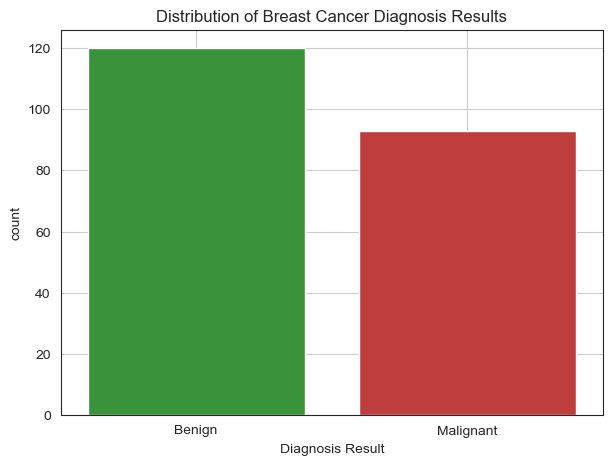

In [49]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, x='Diagnosis Result', hue='Diagnosis Result', palette=['tab:green','tab:red'])
plt.title('Distribution of Breast Cancer Diagnosis Results')
plt.grid();

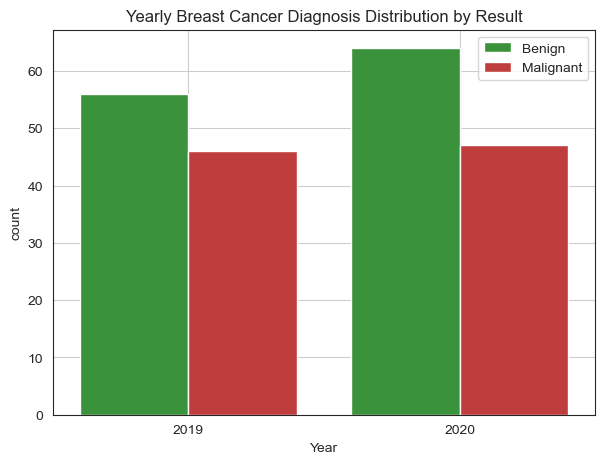

In [50]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, x='Year', hue='Diagnosis Result', palette=['tab:green','tab:red'])
plt.title('Yearly Breast Cancer Diagnosis Distribution by Result')
plt.legend(bbox_to_anchor=(1,1))
plt.grid();

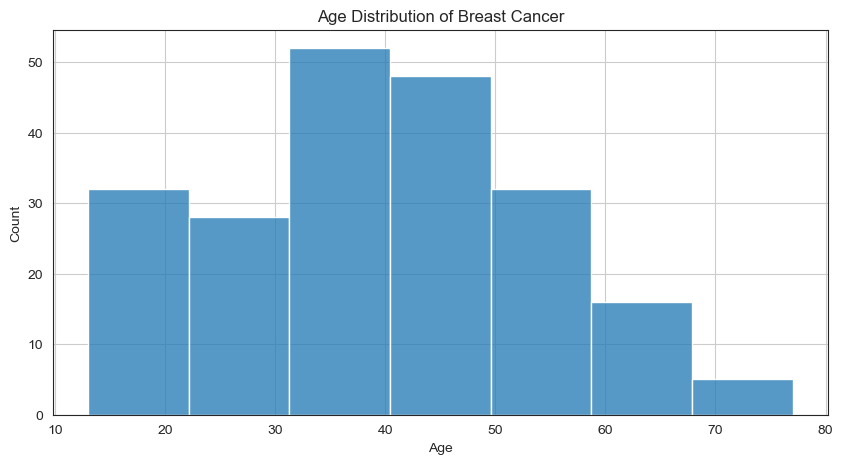

In [51]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='Age', bins=7, color='tab:blue')
plt.title('Age Distribution of Breast Cancer')
plt.grid();

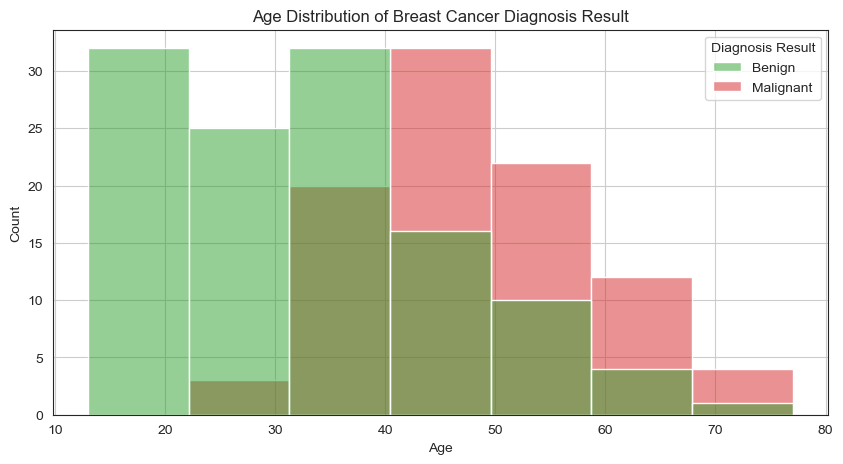

In [52]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='Age', bins=7, palette=['tab:green','tab:red'], hue='Diagnosis Result', multiple='layer')
plt.title('Age Distribution of Breast Cancer Diagnosis Result')
plt.grid();

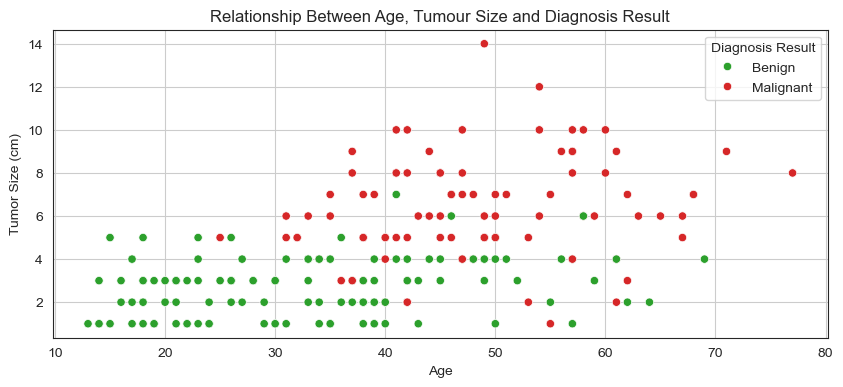

In [53]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=data,x='Age', y='Tumor Size (cm)', hue='Diagnosis Result', palette=['tab:green','tab:red'])
plt.title('Relationship Between Age, Tumour Size and Diagnosis Result')
plt.grid();

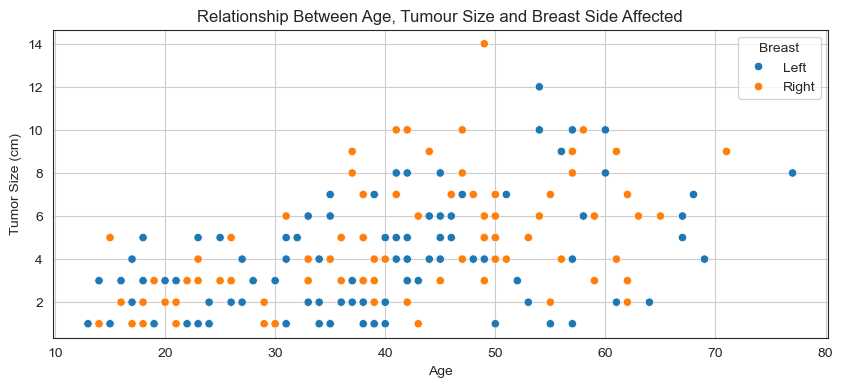

In [54]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=data,x='Age', y='Tumor Size (cm)', hue='Breast')
plt.title('Relationship Between Age, Tumour Size and Breast Side Affected')
plt.grid();

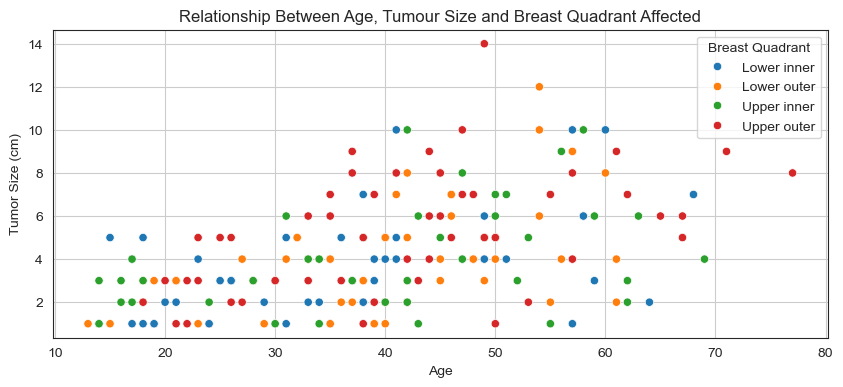

In [55]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=data,x='Age', y='Tumor Size (cm)', hue='Breast Quadrant')
plt.title('Relationship Between Age, Tumour Size and Breast Quadrant Affected')
plt.grid();

In [56]:
g = data.groupby('Menopause', as_index=False).size()
g

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\3493122808.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby('Menopause', as_index=False).size()


,Menopause,size
0,Post Menopause,71
1,Pre Menopause,142


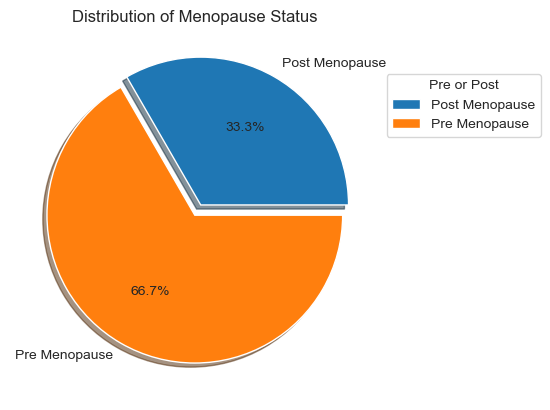

In [57]:
plt.pie(x=g['size'].unique(), labels=g['Menopause'].unique(), shadow=True,explode=[0.08,0], autopct ='%.1f%%')
plt.title('Distribution of Menopause Status')
plt.legend(title='Pre or Post', bbox_to_anchor =(1,0.9), ncol = 1);

In [58]:
h = data.groupby('Metastasis', as_index=False).size()
h

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\300391392.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h = data.groupby('Metastasis', as_index=False).size()


,Metastasis,size
0,No,140
1,Yes,73


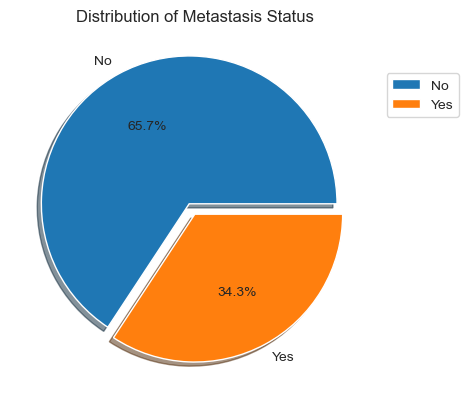

In [59]:
plt.pie(x=h['size'].unique(), labels=h['Metastasis'].unique(), shadow=True,explode=[0.08,0], autopct ='%.1f%%')
plt.legend(title='', bbox_to_anchor =(1,0.9), ncol = 1)
plt.title('Distribution of Metastasis Status');

# **Medical Questions**

## **1. What percentage of patients were diagnosed with malignant breast cancer**

In [60]:
i = data.groupby('Diagnosis Result', as_index=False).size()
i['Percentage'] = ((((i['size']/i['size'].sum())*100).round(1)).astype('str')) + '%'
i

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\1712603851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  i = data.groupby('Diagnosis Result', as_index=False).size()


,Diagnosis Result,size,Percentage
0,Benign,120,56.3%
1,Malignant,93,43.7%


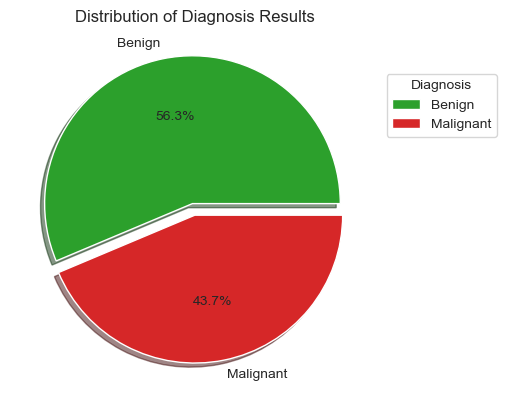

In [61]:
plt.pie(x=i['size'].unique(), labels=i['Diagnosis Result'].unique(), shadow=True,explode=[0.08,0], autopct ='%.1f%%', colors=['tab:green','tab:red'])
plt.legend(title='Diagnosis', bbox_to_anchor =(1,0.9), ncol = 1)
plt.title('Distribution of Diagnosis Results');

## **2. Which age group is most vulnerable?**

In [62]:
list1 = list()
for age in data['Age']:
    if age <= 20:
        list1.append('less than 20')    # Creating a new column for the Age group   
    elif age <=30:
        list1.append('20 to 30')
    elif age <=40:
        list1.append('30 to 40')
    elif age <=50:
        list1.append('40 to 50')
    elif age <=60:
        list1.append('50 to 60')
    elif age <=70:
        list1.append('60 to 70')
    else:
        list1.append('older than 70')

data['Age group'] = list1
data.head(5)

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result,Age group
0,1,2019,40,Pre Menopause,2,0,Right,No,Upper inner,No,Benign,30 to 40
1,2,2019,39,Pre Menopause,2,0,Left,No,Upper outer,No,Benign,30 to 40
2,3,2019,45,Post Menopause,4,0,Left,No,Lower outer,No,Benign,40 to 50
3,4,2019,26,Pre Menopause,3,0,Left,No,Lower inner,Yes,Benign,20 to 30
4,5,2019,21,Pre Menopause,1,0,Right,No,Upper outer,Yes,Benign,20 to 30


In [63]:
o = data.sort_values('Age', ascending=True)

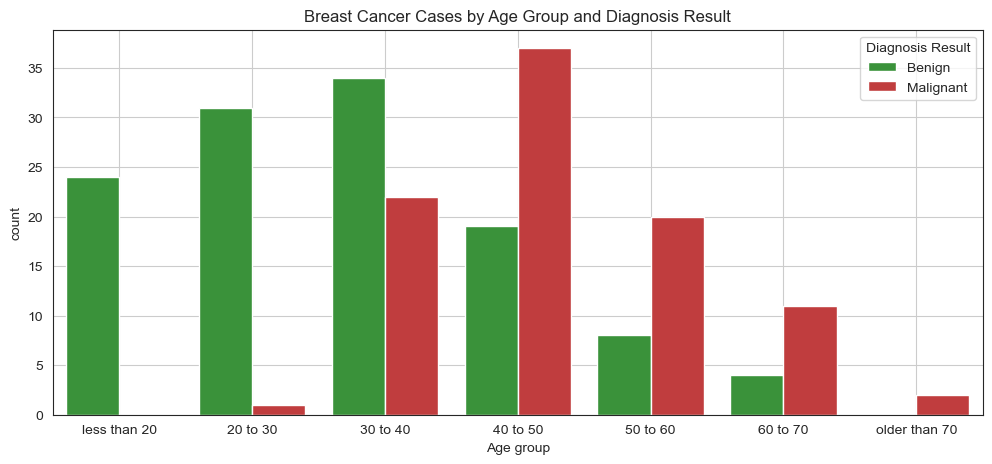

In [64]:
p = plt.figure(figsize=(12,5))
sns.countplot(data=o, hue='Diagnosis Result', x='Age group', palette=['tab:green','tab:red'])
plt.title('Breast Cancer Cases by Age Group and Diagnosis Result')
plt.grid();

## **3. Did cancer cases increase in 2020?**

In [65]:
j = data.groupby(['Year', 'Diagnosis Result'], as_index=False).size()
j

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\3930829330.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  j = data.groupby(['Year', 'Diagnosis Result'], as_index=False).size()


,Year,Diagnosis Result,size
0,2019,Benign,56
1,2019,Malignant,46
2,2020,Benign,64
3,2020,Malignant,47


## **4. Are larger tumours usually malignant?**

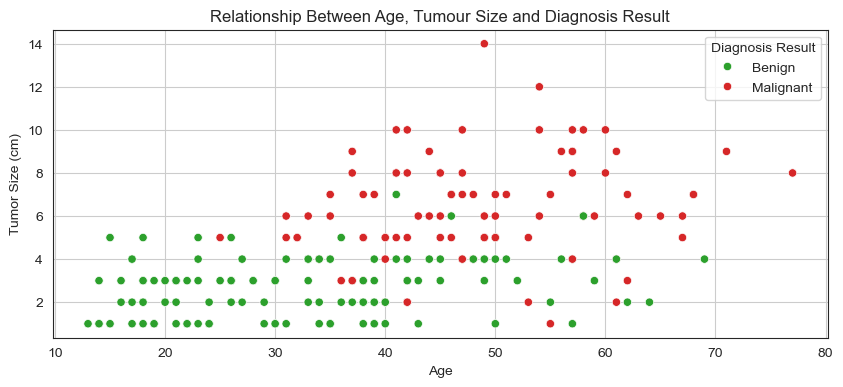

In [66]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=data,x='Age', y='Tumor Size (cm)', hue='Diagnosis Result', palette=['tab:green','tab:red'])
plt.title('Relationship Between Age, Tumour Size and Diagnosis Result')
plt.grid();

## **5. Does menopause increase malignant diagnosis risk?**

In [67]:
k = data.groupby(['Menopause', 'Diagnosis Result'], as_index=False).size()
k

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\2361370791.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  k = data.groupby(['Menopause', 'Diagnosis Result'], as_index=False).size()


,Menopause,Diagnosis Result,size
0,Post Menopause,Benign,21
1,Post Menopause,Malignant,50
2,Pre Menopause,Benign,99
3,Pre Menopause,Malignant,43


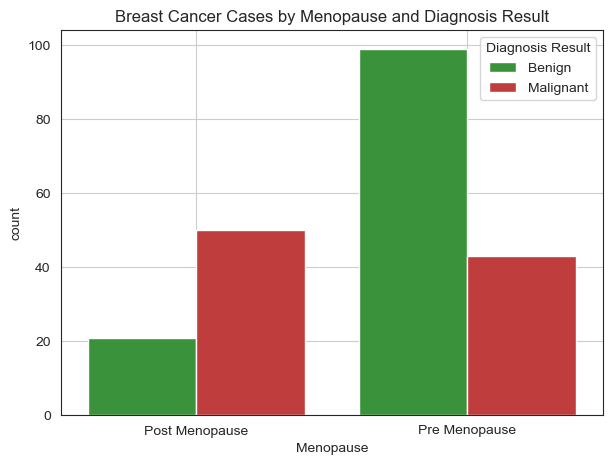

In [68]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, hue='Diagnosis Result', x='Menopause', palette=['tab:green','tab:red'])
plt.title('Breast Cancer Cases by Menopause and Diagnosis Result')
plt.grid();

## **6. How strongly is metastasis connected to malignancy?**

In [69]:
l = data.groupby(['Metastasis', 'Diagnosis Result'], as_index=False).size()
l

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\258956277.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  l = data.groupby(['Metastasis', 'Diagnosis Result'], as_index=False).size()


,Metastasis,Diagnosis Result,size
0,No,Benign,116
1,No,Malignant,24
2,Yes,Benign,4
3,Yes,Malignant,69


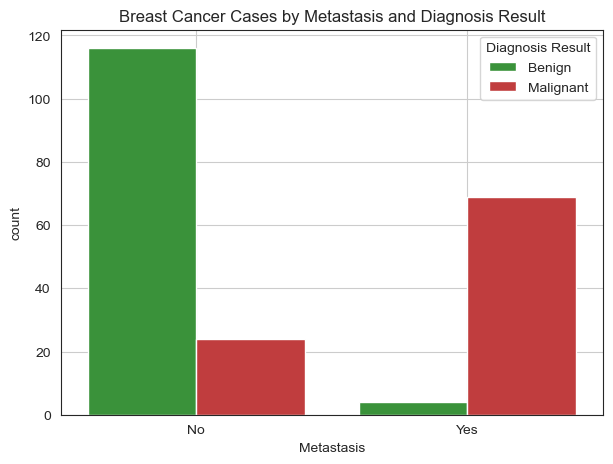

In [70]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, hue='Diagnosis Result', x='Metastasis', palette=['tab:green','tab:red'])
plt.title('Breast Cancer Cases by Metastasis and Diagnosis Result')
plt.grid();

## **7. Which breast quadrant is most commonly affected?**

In [71]:
m = data.groupby(['Breast Quadrant', 'Diagnosis Result'], as_index=False).size()
m[m['Diagnosis Result'] == 'Malignant']

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\4077033818.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m = data.groupby(['Breast Quadrant', 'Diagnosis Result'], as_index=False).size()


,Breast Quadrant,Diagnosis Result,size
1,Lower inner,Malignant,9
3,Lower outer,Malignant,19
5,Upper inner,Malignant,22
7,Upper outer,Malignant,43


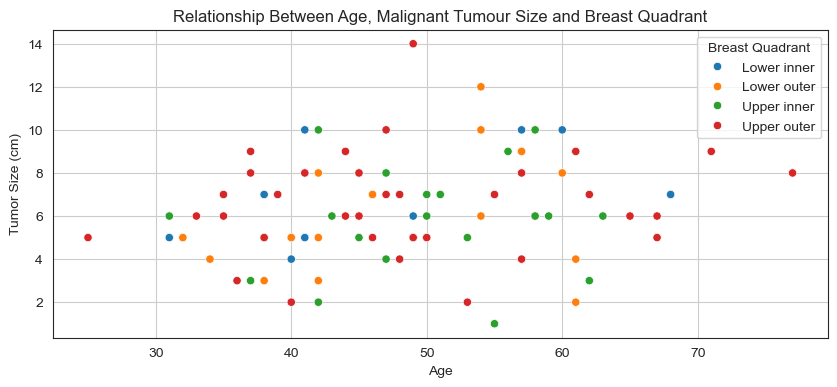

In [72]:
m1 = data[data['Diagnosis Result'] == 'Malignant']
plt.figure(figsize=(10,4))
sns.scatterplot(data=m1 ,x='Age', y='Tumor Size (cm)', hue='Breast Quadrant')
plt.title('Relationship Between Age, Malignant Tumour Size and Breast Quadrant')
plt.grid();

## **8. Are patients with medical history at greater risk?**

In [73]:
n = data.groupby(['History', 'Diagnosis Result'], as_index=False).size()
n

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\2064127139.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n = data.groupby(['History', 'Diagnosis Result'], as_index=False).size()


,History,Diagnosis Result,size
0,No,Benign,81
1,No,Malignant,45
2,Yes,Benign,39
3,Yes,Malignant,48


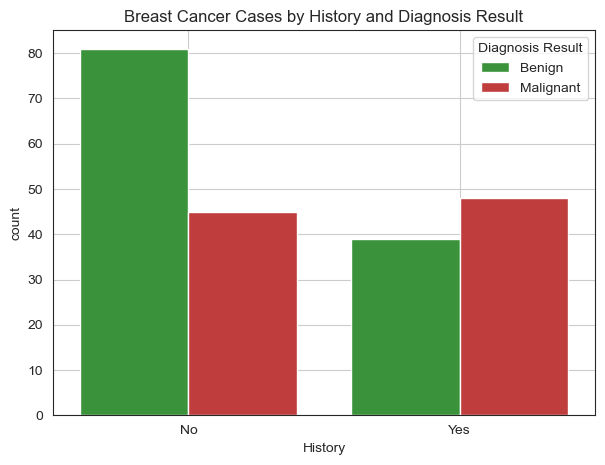

In [74]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, hue='Diagnosis Result', x='History', palette=['tab:green','tab:red'])
plt.title('Breast Cancer Cases by History and Diagnosis Result')
plt.grid();

## **9. Can involved lymph nodes help predict severity?**

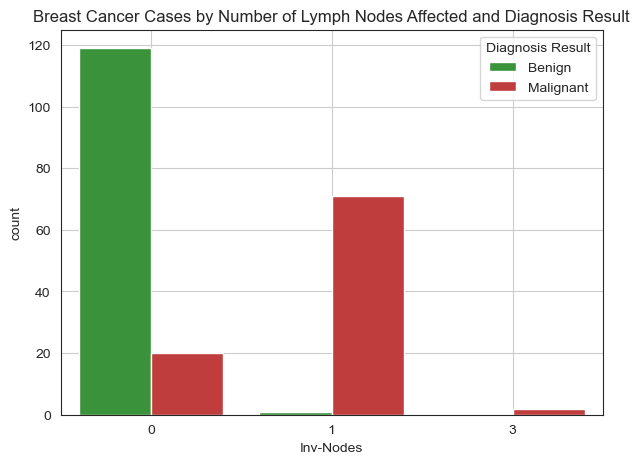

In [75]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, hue='Diagnosis Result', x='Inv-Nodes', palette=['tab:green','tab:red'])
plt.title('Breast Cancer Cases by Number of Lymph Nodes Affected and Diagnosis Result')
plt.grid();

In [76]:
t = data.groupby(['Inv-Nodes', 'Diagnosis Result'], as_index=False).size()
t

C:\Users\DELL\AppData\Local\Temp\ipykernel_12168\3161716978.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = data.groupby(['Inv-Nodes', 'Diagnosis Result'], as_index=False).size()


,Inv-Nodes,Diagnosis Result,size
0,0,Benign,119
1,0,Malignant,20
2,1,Benign,1
3,1,Malignant,71
4,3,Benign,0
5,3,Malignant,2


## **10. Which factors appear most associated with malignant diagnosis?**

**Age, Menopause, Tumor Size, Lymph Node, Metastasis, History**

In [77]:
data.sample(5)

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result,Age group
28,29,2019,36,Pre Menopause,5,0,Right,No,Lower inner,Yes,Benign,30 to 40
29,30,2019,42,Pre Menopause,3,0,Left,No,Lower outer,Yes,Malignant,40 to 50
53,54,2019,47,Post Menopause,4,1,Right,Yes,Upper inner,No,Malignant,40 to 50
166,167,2020,62,Post Menopause,3,1,Right,Yes,Upper inner,Yes,Malignant,60 to 70
114,115,2020,36,Pre Menopause,2,0,Left,No,Lower outer,Yes,Benign,30 to 40


In [78]:
data.to_csv(r'C:\Users\DELL\Desktop\New folder\cleaned-breast-cancer-dataset.csv', index=None, header=True)
# Saving the Cleaned modified Dataset in a new CSV file as 'cleaned-breast-cancer-dataset.csv'

In [79]:
os.listdir(r'C:\Users\DELL\Desktop\New folder')
# Checking for its location to confirmed if it has been saved or not

['ademola_abraham_transcript.pdf',
 'cleaned-breast-cancer-dataset.csv',
 'Data Analysis.pdf',
 'ECG-Sample-Report.pdf',
 'Presentation2.pptx',
 'python_cleaned_superstore_dataset.csv',
 'Supermarket sales data across the US.xlsx']